<a href="https://colab.research.google.com/github/prasenjit200/course-platform-backend/blob/master/weather_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix


In [ ]:
weather_data = pd.read_csv('/content/weather_forecast.csv', parse_dates=['date_time'], index_col='date_time')
weather_data.head()

,maxtempC,mintempC,totalSnow_cm,sunHour,uvIndex,uvIndex.1,moon_illumination,moonrise,moonset,sunrise,...,WindGustKmph,cloudcover,humidity,precipMM,pressure,tempC,visibility,winddirDegree,windspeedKmph,Rain
date_time,,,,,,,,,,,,,,,,,,,,,
01-01-2009 00:00,24.0,10,0,8.7,4,1,31,9:56 AM,9:45 PM,6:57 AM,...,21,17,50,0.0,1015,11,10,320,10.0,0
01-01-2009 01:00,24.0,10,0,8.7,4,1,31,9:56 AM,9:45 PM,6:57 AM,...,22,11,52,0.0,1015,11,10,315,NaN,0
01-01-2009 02:00,24.0,10,0,8.7,4,1,31,9:56 AM,9:45 PM,6:57 AM,...,23,6,55,0.0,1015,11,10,310,NaN,0
01-01-2009 03:00,24.0,10,0,8.7,4,1,31,9:56 AM,9:45 PM,6:57 AM,...,23,0,57,0.0,1015,10,10,304,NaN,0
01-01-2009 04:00,24.0,10,0,8.7,4,1,31,9:56 AM,9:45 PM,6:57 AM,...,19,0,54,0.0,1016,11,10,302,NaN,0


In [ ]:
weather_data.shape

(96432, 25)

In [ ]:
weather_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96432 entries, 01-01-2009 00:00 to 01-01-2020 23:00
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   maxtempC           92729 non-null  float64
 1   mintempC           96432 non-null  int64  
 2   totalSnow_cm       96432 non-null  int64  
 3   sunHour            96432 non-null  float64
 4   uvIndex            96432 non-null  int64  
 5   uvIndex.1          96432 non-null  int64  
 6   moon_illumination  96432 non-null  int64  
 7   moonrise           96432 non-null  object 
 8   moonset            96432 non-null  object 
 9   sunrise            96432 non-null  object 
 10  sunset             96432 non-null  object 
 11  DewPointC          96432 non-null  int64  
 12  FeelsLikeC         96432 non-null  int64  
 13  HeatIndexC         96432 non-null  int64  
 14  WindChillC         96432 non-null  int64  
 15  WindGustKmph       96432 non-null  int64  
 16  c

In [ ]:
weather_data.isnull()

,maxtempC,mintempC,totalSnow_cm,sunHour,uvIndex,uvIndex.1,moon_illumination,moonrise,moonset,sunrise,...,WindGustKmph,cloudcover,humidity,precipMM,pressure,tempC,visibility,winddirDegree,windspeedKmph,Rain
date_time,,,,,,,,,,,,,,,,,,,,,
01-01-2009 00:00,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
01-01-2009 01:00,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
01-01-2009 02:00,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
01-01-2009 03:00,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
01-01-2009 04:00,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
01-01-2020 19:00,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
01-01-2020 20:00,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
01-01-2020 21:00,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
print("Columns:", weather_data.columns)
weather_data.describe()

Columns: Index(['maxtempC', 'mintempC', 'totalSnow_cm', 'sunHour', 'uvIndex',
       'uvIndex.1', 'moon_illumination', 'moonrise', 'moonset', 'sunrise',
       'sunset', 'DewPointC', 'FeelsLikeC', 'HeatIndexC', 'WindChillC',
       'WindGustKmph', 'cloudcover', 'humidity', 'precipMM', 'pressure',
       'tempC', 'visibility', 'winddirDegree', 'windspeedKmph', 'Rain'],
      dtype='object')


,maxtempC,mintempC,totalSnow_cm,sunHour,uvIndex,uvIndex.1,moon_illumination,DewPointC,FeelsLikeC,HeatIndexC,...,WindGustKmph,cloudcover,humidity,precipMM,pressure,tempC,visibility,winddirDegree,windspeedKmph,Rain
count,92729.000000,96432.000000,96432.0,96432.000000,96432.000000,96432.000000,96432.000000,96432.000000,96432.000000,96432.00000,...,96432.000000,96432.000000,96432.000000,96432.000000,96432.000000,96432.000000,96432.000000,96432.000000,89713.000000,96432.000000
mean,33.287084,22.374564,0.0,11.037805,6.877053,4.465012,46.094077,13.230629,30.735783,30.86884,...,14.211766,16.993550,44.370479,0.037756,1006.217946,27.429577,9.885214,205.537270,9.732659,0.046188
std,6.969255,7.635253,0.0,2.152973,1.551294,3.414374,31.249725,8.053778,9.320398,9.17754,...,6.926605,23.150025,22.484991,0.307143,7.593850,8.459575,1.058515,104.369548,4.866629,0.209893
min,15.000000,3.000000,0.0,4.000000,3.000000,1.000000,0.000000,-14.000000,4.000000,7.00000,...,0.000000,0.000000,2.000000,0.000000,986.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28.000000,16.000000,0.0,8.700000,6.000000,1.000000,18.000000,7.000000,24.000000,25.00000,...,9.000000,0.000000,26.000000,0.000000,1000.000000,21.000000,10.000000,101.000000,6.000000,0.000000
50%,34.000000,24.000000,0.0,11.600000,7.000000,5.000000,46.000000,12.000000,31.000000,31.00000,...,14.000000,5.000000,42.000000,0.000000,1006.000000,28.000000,10.000000,240.000000,9.000000,0.000000
75%,38.000000,28.000000,0.0,13.000000,8.000000,8.000000,73.000000,21.000000,38.000000,38.00000,...,18.000000,27.000000,61.000000,0.000000,1013.000000,33.000000,10.000000,299.000000,12.000000,0.000000
max,51.000000,39.000000,0.0,13.900000,11.000000,11.000000,100.000000,31.000000,65.000000,65.00000,...,75.000000,100.000000,100.000000,20.600000,1024.000000,50.000000,20.000000,360.000000,47.000000,1.000000


<Axes: ylabel='date_time'>

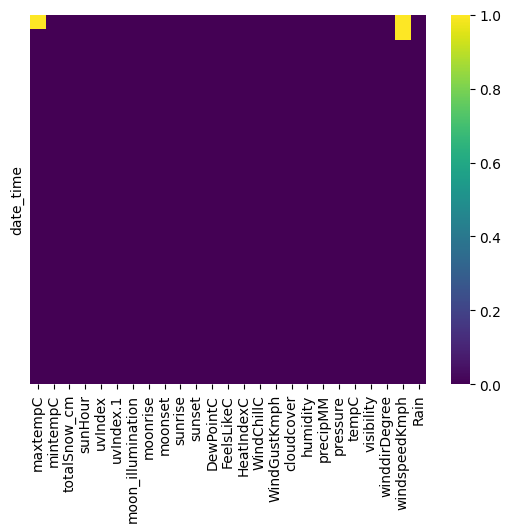

In [ ]:
sns.heatmap(weather_data.isnull(), yticklabels = False, cbar = True, cmap = 'viridis' )

In [ ]:
weather_data.corr(numeric_only=True)

,maxtempC,mintempC,totalSnow_cm,sunHour,uvIndex,uvIndex.1,moon_illumination,DewPointC,FeelsLikeC,HeatIndexC,...,WindGustKmph,cloudcover,humidity,precipMM,pressure,tempC,visibility,winddirDegree,windspeedKmph,Rain
maxtempC,1.000000,0.887799,NaN,0.781966,0.946195,0.241158,-0.027502,0.164123,0.821594,0.820746,...,0.054342,0.011743,-0.443641,-0.019062,-0.774953,0.869308,0.072488,-0.117919,0.205076,-0.028439
mintempC,0.887799,1.000000,NaN,0.744942,0.913161,0.217436,-0.016930,0.469920,0.873623,0.872525,...,0.067802,0.302925,-0.148172,0.060246,-0.882492,0.870461,-0.027760,-0.220238,0.251444,0.095113
totalSnow_cm,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sunHour,0.781966,0.744942,NaN,1.000000,0.754874,0.194483,-0.024647,0.242303,0.705933,0.704134,...,0.106486,0.092732,-0.245537,-0.006989,-0.753522,0.710758,0.041349,-0.098618,0.258496,-0.003995
uvIndex,0.946195,0.913161,NaN,0.754874,1.000000,0.233236,-0.022649,0.225289,0.820046,0.819260,...,0.037093,0.052818,-0.386380,-0.018719,-0.777343,0.860180,0.078323,-0.138462,0.202161,-0.029727
uvIndex.1,0.241158,0.217436,NaN,0.194483,0.233236,1.000000,-0.008186,0.004369,0.525719,0.525129,...,-0.066426,0.002691,-0.379412,0.001941,-0.202573,0.554912,0.055872,0.093894,0.191264,-0.002621
moon_illumination,-0.027502,-0.016930,NaN,-0.024647,-0.022649,-0.008186,1.000000,0.001654,-0.017124,-0.017854,...,0.002350,0.035678,0.018023,0.018666,-0.003849,-0.020616,-0.001492,0.004984,0.006497,0.025527
DewPointC,0.164123,0.469920,NaN,0.242303,0.225289,0.004369,0.001654,1.000000,0.436862,0.438039,...,-0.105261,0.598397,0.692128,0.165214,-0.512610,0.267693,-0.206422,-0.371298,0.005133,0.257062
FeelsLikeC,0.821594,0.873623,NaN,0.705933,0.820046,0.525719,-0.017124,0.436862,1.000000,0.998714,...,-0.080134,0.228363,-0.255690,0.053347,-0.824692,0.958251,-0.015946,-0.153756,0.193175,0.082243
HeatIndexC,0.820746,0.872525,NaN,0.704134,0.819260,0.525129,-0.017854,0.438039,0.998714,1.000000,...,-0.080591,0.225983,-0.253712,0.052894,-0.823792,0.955932,-0.015712,-0.153221,0.192652,0.082260


In [ ]:
weather_data_num = weather_data.loc[:, ['maxtempC', 'mintempC', 'cloudcover', 'humidity', 'tempC',
                                        'sunHour', 'HeatIndexC', 'pressure', 'windspeedKmph','Rain']]
weather_data_num.head()

,maxtempC,mintempC,cloudcover,humidity,tempC,sunHour,HeatIndexC,pressure,windspeedKmph,Rain
date_time,,,,,,,,,,
01-01-2009 00:00,24.0,10,17,50,11,8.7,12,1015,10.0,0
01-01-2009 01:00,24.0,10,11,52,11,8.7,13,1015,NaN,0
01-01-2009 02:00,24.0,10,6,55,11,8.7,13,1015,NaN,0
01-01-2009 03:00,24.0,10,0,57,10,8.7,13,1015,NaN,0
01-01-2009 04:00,24.0,10,0,54,11,8.7,14,1016,NaN,0


In [ ]:
weather_data_num.fillna(weather_data_num.mean(), inplace=True)
print("Missing Values After Filling:", weather_data_num.isnull().any())

Missing Values After Filling: maxtempC         False
mintempC         False
cloudcover       False
humidity         False
tempC            False
sunHour          False
HeatIndexC       False
pressure         False
windspeedKmph    False
Rain             False
dtype: bool


<Axes: >

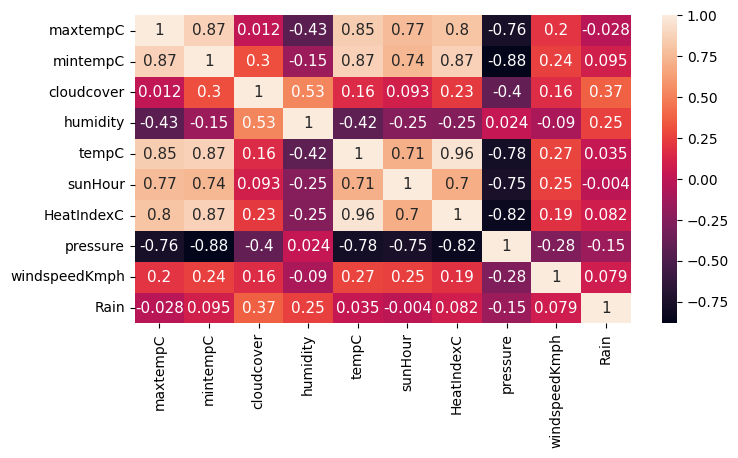

In [ ]:
plt.figure(figsize = (8, 4))
sns.heatmap(weather_data_num.corr(numeric_only=True) , annot = True, annot_kws = {"size":11})

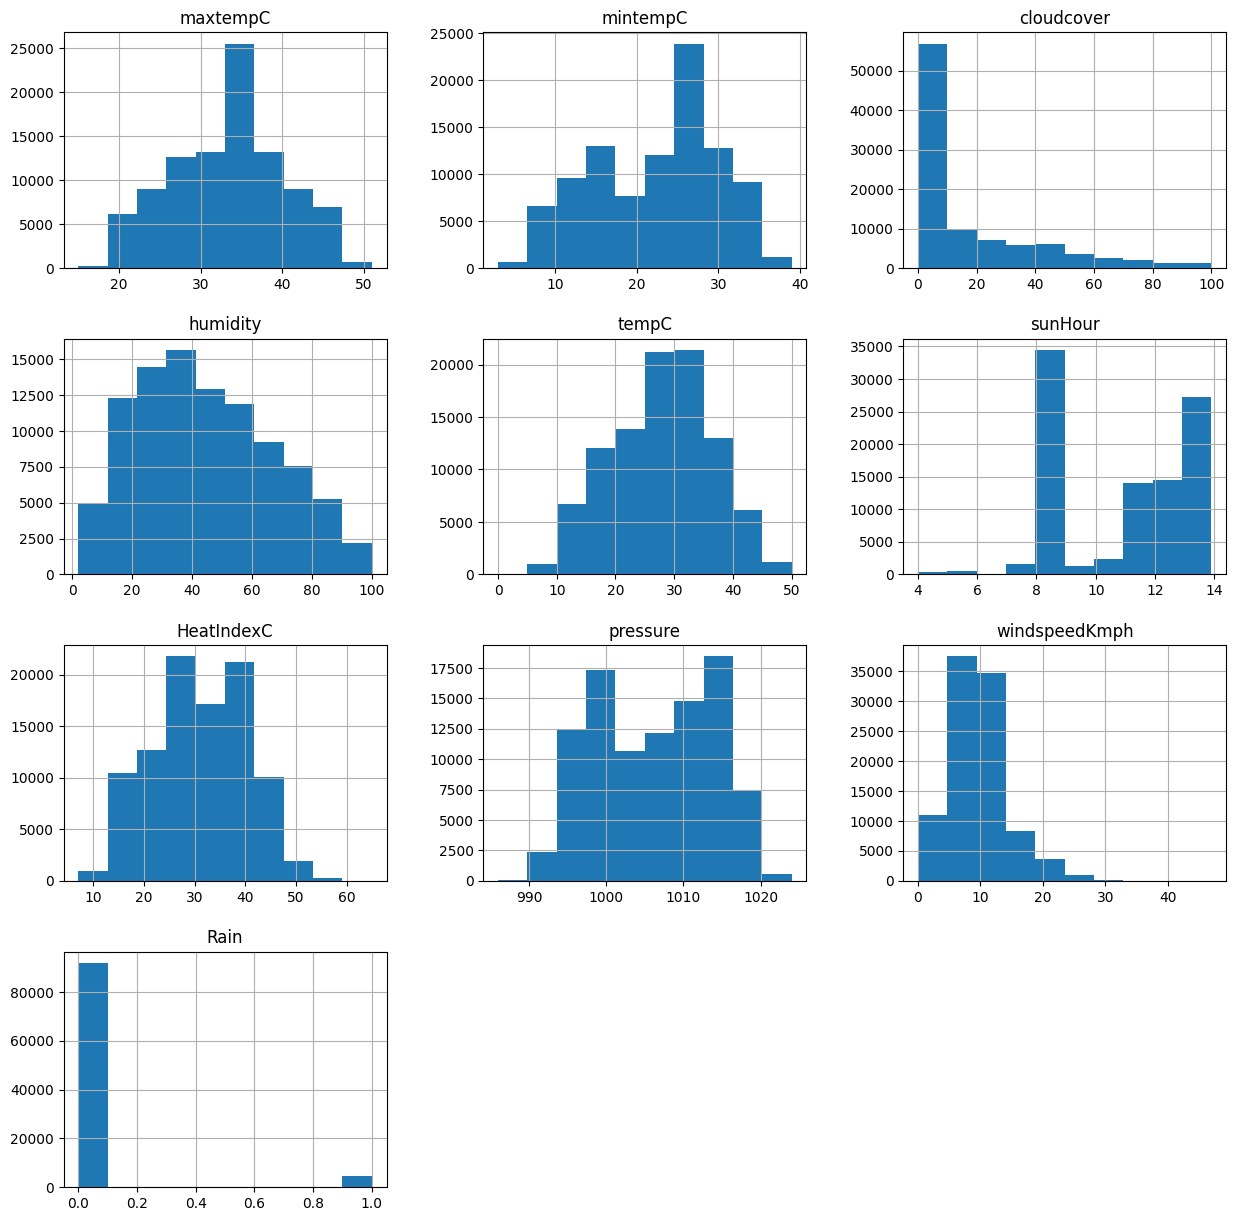

In [ ]:
weather_data_num.hist(bins=10, figsize=(15, 15))
plt.show()

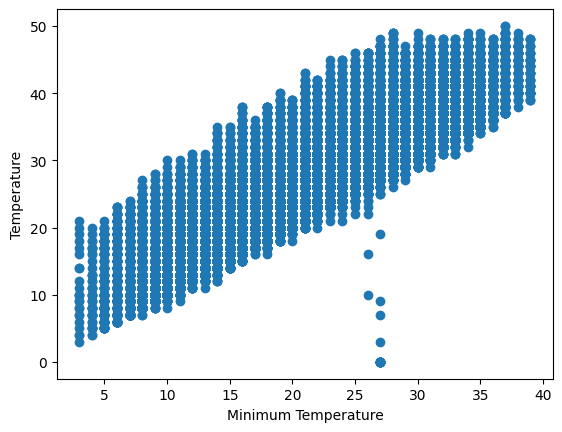

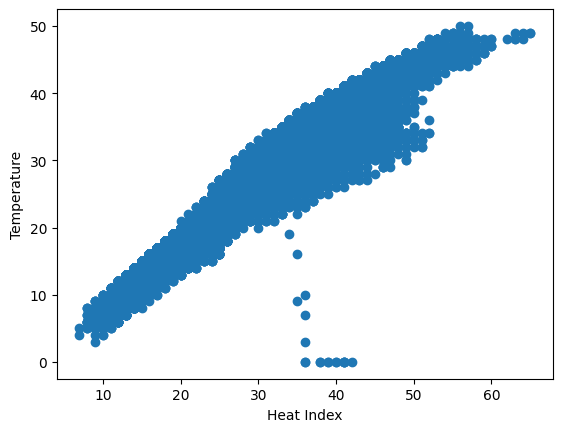

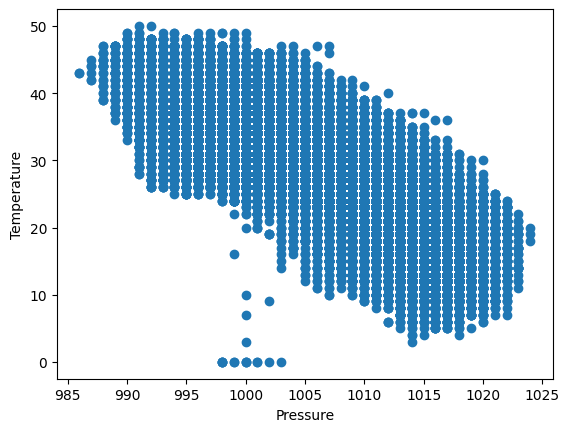

In [ ]:
# Minimum Temperature vs. Temperature
plt.scatter(weather_data_num['mintempC'], weather_data_num['tempC'])
plt.xlabel("Minimum Temperature")
plt.ylabel("Temperature")
plt.show()

# Heat Index vs. Temperature
plt.scatter(weather_data_num['HeatIndexC'], weather_data_num['tempC'])
plt.xlabel("Heat Index")
plt.ylabel("Temperature")
plt.show()

# Pressure vs. Temperature
plt.scatter(weather_data_num['pressure'], weather_data_num['tempC'])
plt.xlabel("Pressure")
plt.ylabel("Temperature")
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
weather_y = weather_data_num.pop("tempC")
weather_x = weather_data_num


In [ ]:
train_X, test_X, train_y, test_y = train_test_split(weather_x, weather_y, test_size=0.2, random_state=4)
print("Training Features Shape:", train_X.shape)
print("Training Target Shape:", train_y.shape)
print("Testing Features Shape:", test_X.shape)
print("Testing Target Shape:", test_y.shape)

Training Features Shape: (77145, 9)
Training Target Shape: (77145,)
Testing Features Shape: (19287, 9)
Testing Target Shape: (19287,)


In [ ]:
model = LinearRegression()
model.fit(train_X, train_y)


LinearRegression()

In [ ]:
prediction = model.predict(test_X)

In [ ]:
MAE = mean_absolute_error(test_y, prediction)
MSE = mean_squared_error(test_y, prediction)
RMSE = np.sqrt(MSE)
R2 = r2_score(test_y, prediction)

print("Regression Metrics:")
print(f"MAE: {MAE:.3f}, MSE: {MSE:.3f}, RMSE: {RMSE:.3f}, R2: {R2:.3f}")


Regression Metrics:
MAE: 1.210, MSE: 2.550, RMSE: 1.597, R2: 0.964


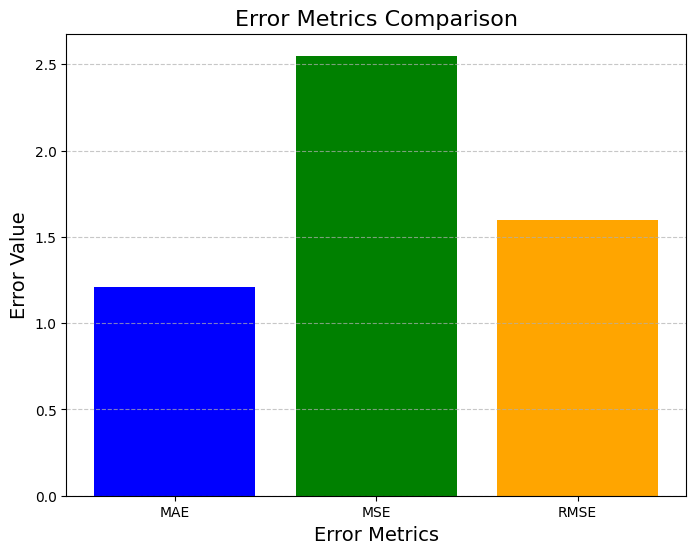

In [ ]:
errors = [MAE, MSE, RMSE]
labels = ['MAE', 'MSE', 'RMSE']
plt.figure(figsize=(8, 6))
plt.bar(labels, errors, color=['blue', 'green', 'orange'])
plt.title('Error Metrics Comparison', fontsize=16)
plt.xlabel('Error Metrics', fontsize=14)
plt.ylabel('Error Value', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
X_clf = weather_x.drop('Rain', axis=1)
y_clf = weather_x['Rain']


In [ ]:
train_X_clf, test_X_clf, train_y_clf, test_y_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)


In [ ]:
clf_model = LogisticRegression()
clf_model.fit(train_X_clf, train_y_clf)

LogisticRegression()

In [ ]:
rain_predictions = clf_model.predict(test_X_clf)


In [ ]:
# Accuracy
accuracy = accuracy_score(test_y_clf, rain_predictions)
print(f"Accuracy: {accuracy:.3f}")

# Classification Report
print("\nClassification Report:\n", classification_report(test_y_clf, rain_predictions))

# Confusion Matrix
conf_matrix = confusion_matrix(test_y_clf, rain_predictions)
print("\nConfusion Matrix:\n", conf_matrix)

Accuracy: 0.949

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97     18359
           1       0.29      0.05      0.08       928

    accuracy                           0.95     19287
   macro avg       0.62      0.52      0.53     19287
weighted avg       0.92      0.95      0.93     19287


Confusion Matrix:
 [[18254   105]
 [  886    42]]


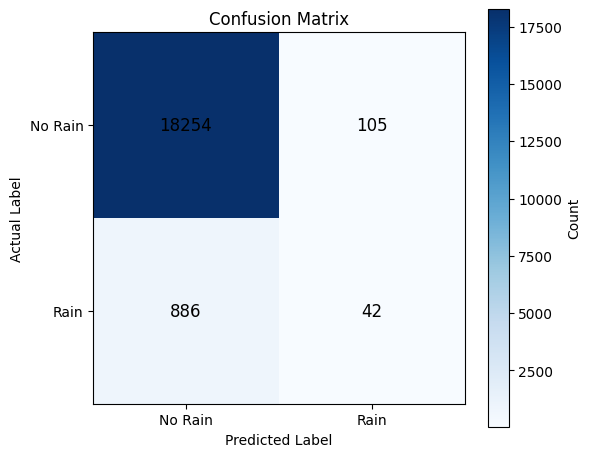

In [ ]:
plt.figure(figsize=(6, 5))
plt.title("Confusion Matrix")
plt.imshow(conf_matrix, cmap='Blues', interpolation='nearest')
plt.colorbar(label="Count")

# Adding axis labels
plt.xticks([0, 1], ['No Rain', 'Rain'])
plt.yticks([0, 1], ['No Rain', 'Rain'])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

# Adding text annotations for the confusion matrix values
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(j, i, str(conf_matrix[i, j]), ha="center", va="center", color="black", fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:

for i in range(len(prediction)):
    prediction[i] = round(prediction[i], 2)

combined_results = pd.DataFrame({
    'Actual Temp': test_y.values,
    'Predicted Temp': prediction,
    'Temp Difference': test_y.values - prediction,
    'Actual Rain': test_y_clf.values,
    'Predicted Rain': rain_predictions,
    'Rain Correct?': test_y_clf.values == rain_predictions
})
# Display the first few rows of the DataFrame
combined_results.head()



,Actual Temp,Predicted Temp,Temp Difference,Actual Rain,Predicted Rain,Rain Correct?
0,34,34.95,-0.95,0,0,True
1,25,24.58,0.42,0,0,True
2,34,35.17,-1.17,0,0,True
3,28,25.17,2.83,0,0,True
4,28,28.05,-0.05,0,0,True
